# Detección de anomalías en BTC/USDT con modelos representativos

Este notebook integra una versión reducida y defendible de la metodología para detección de anomalías en el mercado de criptomonedas. Se comparan cinco enfoques principales: Z-Score como baseline estadístico, LOF como modelo clásico no supervisado, Isolation Forest como modelo basado en aislamiento, Normalizing Flow como modelo profundo generativo y DeepAR como modelo temporal probabilístico.

La estructura responde a las observaciones metodológicas relacionadas con validación sin etiquetas, uso del Z-Score solo como referencia, justificación de contaminación, validación temporal, interpretación financiera de anomalías y reproducibilidad.


## 1. Configuración del entorno y reproducibilidad

En esta sección se cargan librerías, se establece la semilla aleatoria y se documenta la configuración base del experimento. Antes de ejecutar el notebook, modifica la variable `DATA_PATH` con la ubicación del archivo CSV extraído de Binance.

In [1]:
import os
import sys
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, TensorDataset
    torch.manual_seed(SEED)
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch no está disponible:", e)

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("Semilla aleatoria:", SEED)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
pandas: 2.3.3
numpy: 1.26.4
Semilla aleatoria: 42


## 2. Carga de datos

El estudio utiliza datos históricos del par BTC/USDT en intervalos de 15 minutos. Las variables base corresponden al formato OHLCV y se complementan con variables derivadas utilizadas para modelar cambios de precio, volatilidad, rango intraperiodo, intensidad transaccional y presión de compra.

In [2]:
# Modificar esta ruta según la ubicación del archivo en tu equipo
DATA_PATH = r"C:\Users\cecil\Cript_Anomalies\BTCUSDT_20180101_20260112.csv"

df = pd.read_csv(DATA_PATH, delimiter=";")

# Fechas
for col in ["open_time", "close_time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Orden temporal
if "open_time" in df.columns:
    df = df.sort_values("open_time").reset_index(drop=True)

print(df.shape)
display(df.head())

(281131, 21)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,...,ignore,symbol,interval,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,z_return,anomaly_simple
0,2018-01-01 00:00:00+00:00,13715.65,13715.65,13400.01,13556.15,123.616013,2018-01-01 00:14:59.999000+00:00,1.675545e+06,1572,63.227133,...,0,BTCUSDT,15m,NaN,NaN,0.023013,12.716799,0.511480,NaN,False
1,2018-01-01 00:15:00+00:00,13533.75,13550.87,13402.00,13521.12,98.136430,2018-01-01 00:29:59.999000+00:00,1.321757e+06,1461,47.686389,...,0,BTCUSDT,15m,-0.002587,NaN,0.011000,14.887438,0.485919,-0.691986,False
2,2018-01-01 00:30:00+00:00,13500.00,13545.37,13450.00,13470.41,79.904037,2018-01-01 00:44:59.999000+00:00,1.078825e+06,1000,43.710406,...,0,BTCUSDT,15m,-0.003757,NaN,0.007064,12.515012,0.547036,-1.004095,False
3,2018-01-01 00:45:00+00:00,13494.65,13690.87,13450.00,13529.01,141.699719,2018-01-01 00:59:59.999000+00:00,1.917783e+06,1195,73.897993,...,0,BTCUSDT,15m,0.004341,NaN,0.017849,8.433327,0.521511,1.156086,False
4,2018-01-01 01:00:00+00:00,13528.99,13571.74,13402.28,13445.63,72.537533,2018-01-01 01:14:59.999000+00:00,9.778198e+05,898,34.257652,...,0,BTCUSDT,15m,-0.006182,NaN,0.012526,12.379798,0.472275,-1.650855,False


## 3. Construcción y validación de variables derivadas

Las cinco variables utilizadas como entrada de los modelos son: `log_return`, `volatility_20`, `range_hl`, `trades_per_volume` y `buy_ratio`. Estas variables permiten representar dimensiones complementarias del mercado: rendimiento, volatilidad reciente, amplitud del rango de precios, actividad transaccional relativa y proporción de compras.

In [3]:
# Asegurar tipo numérico en columnas relevantes
numeric_cols = [
    "open", "high", "low", "close", "volume", "n_trades",
    "taker_buy_base", "taker_buy_quote", "quote_asset_volume"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Crear variables derivadas si no existen
if "log_return" not in df.columns:
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

if "volatility_20" not in df.columns:
    df["volatility_20"] = df["log_return"].rolling(window=20).std()

if "range_hl" not in df.columns:
    df["range_hl"] = (df["high"] - df["low"]) / df["open"]

if "trades_per_volume" not in df.columns:
    df["trades_per_volume"] = df["n_trades"] / df["volume"]

if "buy_ratio" not in df.columns:
    df["buy_ratio"] = df["taker_buy_base"] / df["volume"]

FEATURES = ["log_return", "volatility_20", "range_hl", "trades_per_volume", "buy_ratio"]

# Limpieza de valores infinitos y nulos en variables de modelado
df[FEATURES] = df[FEATURES].replace([np.inf, -np.inf], np.nan)
df_model = df.dropna(subset=FEATURES).copy().reset_index(drop=True)

print("Observaciones originales:", len(df))
print("Observaciones después de limpieza:", len(df_model))
display(df_model[FEATURES].describe().T)

Observaciones originales: 281131
Observaciones después de limpieza: 281097


,count,mean,std,min,25%,50%,75%,max
log_return,281097.0,0.000007,0.003749,-1.412409e-01,-0.001287,0.000013,0.001333,0.203992
volatility_20,281097.0,0.002881,0.002417,1.445520e-04,0.001480,0.002248,0.003497,0.068645
range_hl,281097.0,0.004511,0.004660,9.140000e-08,0.001996,0.003255,0.005422,0.243322
trades_per_volume,281097.0,55.025161,80.033605,1.320181e+00,11.798272,24.234146,46.845434,890.956160
buy_ratio,281097.0,0.496532,0.086909,5.569881e-02,0.446928,0.496779,0.546465,0.942880


## 4. Definición operativa de anomalía y baseline Z-Score

Para efectos de esta investigación, una anomalía se entiende como una observación que presenta desviaciones significativas respecto al comportamiento habitual del mercado. En términos empíricos, esto puede reflejarse mediante movimientos extremos en los rendimientos, incrementos inusuales en la volatilidad, variaciones atípicas en el rango de precios, cambios abruptos en la actividad transaccional o desequilibrios inusuales entre las operaciones de compra y el volumen negociado.

El Z-Score se utiliza únicamente como baseline estadístico y no como verdad absoluta. Su función es servir como punto de comparación inicial para evaluar consistencia con eventos extremos de rendimiento.

In [4]:
def add_zscore_baseline(df_in, col="log_return", threshold=3):
    d = df_in.copy()
    mu = d[col].mean()
    sigma = d[col].std()
    d["z_return"] = (d[col] - mu) / sigma
    d["anomaly_zscore"] = d["z_return"].abs() > threshold
    d["zscore_score"] = d["z_return"].abs()
    return d

df_model = add_zscore_baseline(df_model)

display(df_model[["log_return", "z_return", "anomaly_zscore"]].head())
print("Anomalías Z-Score:", int(df_model["anomaly_zscore"].sum()))
print("Tasa Z-Score:", df_model["anomaly_zscore"].mean())

,log_return,z_return,anomaly_zscore
0,0.001919,0.510220,False
1,-0.000633,-0.170805,False
2,-0.002831,-0.757048,False
3,-0.001549,-0.415053,False
4,-0.001969,-0.527053,False


Anomalías Z-Score: 4820
Tasa Z-Score: 0.01714710580333479


## 5. Partición temporal para evaluación fuera de muestra

En series financieras no se recomienda mezclar observaciones aleatoriamente. Por ello, se utiliza una partición temporal que respeta el orden de los datos: entrenamiento, validación y prueba. El escalamiento se ajusta únicamente con el conjunto de entrenamiento para evitar fuga de información.

In [5]:
def temporal_split(df_in, train_size=0.70, val_size=0.15):
    d = df_in.sort_values("open_time").reset_index(drop=True) if "open_time" in df_in.columns else df_in.reset_index(drop=True)
    n = len(d)
    train_end = int(n * train_size)
    val_end = int(n * (train_size + val_size))
    train = d.iloc[:train_end].copy()
    val = d.iloc[train_end:val_end].copy()
    test = d.iloc[val_end:].copy()
    return train, val, test

train_df, val_df, test_df = temporal_split(df_model)

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURES])
X_val = scaler.transform(val_df[FEATURES])
X_test = scaler.transform(test_df[FEATURES])

print("Train:", train_df.shape, train_df["open_time"].min() if "open_time" in train_df else None, train_df["open_time"].max() if "open_time" in train_df else None)
print("Validation:", val_df.shape, val_df["open_time"].min() if "open_time" in val_df else None, val_df["open_time"].max() if "open_time" in val_df else None)
print("Test:", test_df.shape, test_df["open_time"].min() if "open_time" in test_df else None, test_df["open_time"].max() if "open_time" in test_df else None)

Train: (196767, 23) 2018-01-01 05:00:00+00:00 2023-08-18 13:00:00+00:00
Validation: (42165, 23) 2023-08-18 13:15:00+00:00 2024-10-30 18:15:00+00:00
Test: (42165, 23) 2024-10-30 18:30:00+00:00 2026-01-12 23:30:00+00:00


## 6. Funciones de evaluación comunes

La evaluación considera métricas descriptivas del score, tasa de anomalías, overlap con Z-Score, estabilidad temporal y criterios financieros. Debido a la ausencia de etiquetas reales, el overlap con Z-Score se interpreta solo como una medida de consistencia con un baseline estadístico.

In [6]:
def evaluar_modelo(df_result, model_name, anomaly_col, score_col, zscore_col="anomaly_zscore"):
    d = df_result.dropna(subset=[anomaly_col, score_col]).copy()
    y_pred = d[anomaly_col].astype(bool)
    scores = d[score_col].astype(float)

    metrics = {
        "modelo": model_name,
        "total_observaciones": len(d),
        "total_anomalias": int(y_pred.sum()),
        "anomaly_rate": float(y_pred.mean()),
        "score_media": float(scores.mean()),
        "score_std": float(scores.std()),
        "score_p95": float(scores.quantile(0.95)),
        "score_p99": float(scores.quantile(0.99)),
        "score_max": float(scores.max()),
    }

    if zscore_col in d.columns:
        z = d[zscore_col].astype(bool)
        denom = max(int(y_pred.sum()), 1)
        metrics["overlap_zscore_pct"] = float(((y_pred & z).sum() / denom) * 100)

    return pd.DataFrame([metrics])


def estabilidad_por_ventana(df_result, anomaly_col, time_col="open_time", freq="Q"):
    d = df_result.dropna(subset=[anomaly_col]).copy()
    if time_col not in d.columns:
        d["window"] = pd.qcut(np.arange(len(d)), q=8, duplicates="drop")
    else:
        d[time_col] = pd.to_datetime(d[time_col])
        d["window"] = d[time_col].dt.to_period(freq).astype(str)
    out = d.groupby("window")[anomaly_col].mean().reset_index(name="anomaly_rate")
    return out


def clasificar_tipo_anomalia(row):
    tipos = []
    if abs(row.get("z_return", 0)) >= 3:
        tipos.append("shock_precio")
    if row.get("volatility_20", 0) >= df_model["volatility_20"].quantile(0.99):
        tipos.append("cambio_volatilidad")
    if row.get("range_hl", 0) >= df_model["range_hl"].quantile(0.99):
        tipos.append("rango_precio_extremo")
    if row.get("trades_per_volume", 0) >= df_model["trades_per_volume"].quantile(0.99):
        tipos.append("actividad_transaccional_extrema")
    if row.get("buy_ratio", 0) >= df_model["buy_ratio"].quantile(0.99) or row.get("buy_ratio", 0) <= df_model["buy_ratio"].quantile(0.01):
        tipos.append("desequilibrio_compra_venta")
    return "mixto" if len(tipos) > 1 else (tipos[0] if tipos else "atipico_multivariado")

## 7. Modelo 1: Z-Score

El Z-Score funciona como baseline estadístico para identificar rendimientos extremos. No se utiliza como etiqueta real, sino como referencia inicial para comparar si otros modelos detectan eventos consistentes con movimientos extremos de precio.

In [7]:
df_z = test_df.copy()
metrics_z = evaluar_modelo(df_z, "Z-Score", "anomaly_zscore", "zscore_score")
display(metrics_z)

,modelo,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_p95,score_p99,score_max,overlap_zscore_pct
0,Z-Score,42165,198,0.004696,0.427748,0.495864,1.289237,2.333333,12.243461,100.0


## 8. Modelo 2: Local Outlier Factor (LOF)

LOF identifica observaciones atípicas a partir de la densidad local de los datos. Se considera un modelo clásico no supervisado basado en vecindad. El parámetro `n_neighbors` permite evaluar la sensibilidad del modelo al tamaño del vecindario.

In [8]:
def fit_lof_train_test(train_df, test_df, features, n_neighbors=20, contamination=0.01):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[features])
    X_test = scaler.transform(test_df[features])

    # novelty=True permite entrenar con train y predecir test
    model = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination,
        novelty=True
    )
    model.fit(X_train)
    pred = model.predict(X_test)
    scores = -model.score_samples(X_test)

    out = test_df.copy()
    out["anomaly_lof"] = pred == -1
    out["lof_score"] = scores
    return out, model, scaler

df_lof, lof_model, lof_scaler = fit_lof_train_test(train_df, test_df, FEATURES, n_neighbors=20, contamination=0.01)
metrics_lof = evaluar_modelo(df_lof, "LOF", "anomaly_lof", "lof_score")
display(metrics_lof)

,modelo,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_p95,score_p99,score_max,overlap_zscore_pct
0,LOF,42165,38441,0.91168,3.573471,2.714067,9.142591,13.579271,27.699309,0.515075


## 9. Modelo 3: Isolation Forest

Isolation Forest detecta anomalías a partir de la facilidad con la que una observación puede ser aislada mediante particiones aleatorias. Se incluye como modelo basado en aislamiento debido a su uso frecuente en problemas aplicados de detección de anomalías.

In [9]:
def fit_isolation_forest_train_test(train_df, test_df, features, contamination=0.01, n_estimators=300, random_state=42):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[features])
    X_test = scaler.transform(test_df[features])

    model = IsolationForest(
        n_estimators=n_estimators,
        contamination=contamination,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train)
    pred = model.predict(X_test)
    scores = -model.score_samples(X_test)

    out = test_df.copy()
    out["anomaly_if"] = pred == -1
    out["if_score"] = scores
    return out, model, scaler

df_if, if_model, if_scaler = fit_isolation_forest_train_test(train_df, test_df, FEATURES, contamination=0.01)
metrics_if = evaluar_modelo(df_if, "Isolation Forest", "anomaly_if", "if_score")
display(metrics_if)

,modelo,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_p95,score_p99,score_max,overlap_zscore_pct
0,Isolation Forest,42165,1789,0.042429,0.582203,0.030244,0.639592,0.664355,0.774273,11.011738


## 10. Modelo 4: Normalizing Flow

Normalizing Flow se incorpora como modelo profundo generativo para estimar la densidad de las observaciones en el espacio de variables derivadas. El score de anomalía se define como la verosimilitud negativa (`-log_prob`): valores más altos indican observaciones menos probables bajo la distribución aprendida y, por tanto, más atípicas.



In [10]:
if TORCH_AVAILABLE:
    class MLP(nn.Module):
        def __init__(self, in_dim, hidden_dim, out_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(in_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, out_dim),
            )

        def forward(self, x):
            return self.net(x)


    class AffineCoupling(nn.Module):
        """Capa de acoplamiento afín tipo RealNVP con máscara binaria."""
        def __init__(self, dim, hidden_dim, mask):
            super().__init__()
            self.dim = dim
            self.register_buffer("mask", mask)
            in_dim = int(mask.sum().item())
            out_dim = dim - in_dim
            self.st_net = MLP(in_dim, hidden_dim, out_dim * 2)

        def forward(self, x):
            x1 = x[:, self.mask.bool()]
            x2 = x[:, (~self.mask.bool())]
            st = self.st_net(x1)
            s, t = st.chunk(2, dim=1)
            s = torch.tanh(s)
            y2 = x2 * torch.exp(s) + t
            y = x.clone()
            y[:, self.mask.bool()] = x1
            y[:, (~self.mask.bool())] = y2
            log_det = s.sum(dim=1)
            return y, log_det

        def inverse(self, y):
            y1 = y[:, self.mask.bool()]
            y2 = y[:, (~self.mask.bool())]
            st = self.st_net(y1)
            s, t = st.chunk(2, dim=1)
            s = torch.tanh(s)
            x2 = (y2 - t) * torch.exp(-s)
            x = y.clone()
            x[:, self.mask.bool()] = y1
            x[:, (~self.mask.bool())] = x2
            log_det = (-s).sum(dim=1)
            return x, log_det


    class RealNVP(nn.Module):
        def __init__(self, dim, n_coupling=6, hidden_dim=128):
            super().__init__()
            self.dim = dim
            layers = []
            for i in range(n_coupling):
                if i % 2 == 0:
                    mask = torch.tensor([1 if j % 2 == 0 else 0 for j in range(dim)], dtype=torch.float32)
                else:
                    mask = torch.tensor([0 if j % 2 == 0 else 1 for j in range(dim)], dtype=torch.float32)
                layers.append(AffineCoupling(dim, hidden_dim, mask))
            self.layers = nn.ModuleList(layers)

        def f(self, x):
            log_det_sum = torch.zeros(x.size(0), device=x.device)
            z = x
            for layer in self.layers:
                z, log_det = layer(z)
                log_det_sum += log_det
            return z, log_det_sum

        def log_prob(self, x):
            z, log_det = self.f(x)
            base_log_prob = -0.5 * (z.pow(2).sum(dim=1) + self.dim * np.log(2 * np.pi))
            return base_log_prob + log_det


    def train_normalizing_flow(
        train_df,
        test_df,
        features,
        contamination=0.01,
        n_coupling=6,
        hidden_dim=128,
        epochs=15,
        batch_size=2048,
        lr=1e-3,
        random_state=42
    ):
        torch.manual_seed(random_state)
        np.random.seed(random_state)

        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_df[features]).astype("float32")
        X_test = scaler.transform(test_df[features]).astype("float32")

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = RealNVP(dim=len(features), n_coupling=n_coupling, hidden_dim=hidden_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loader = DataLoader(TensorDataset(torch.tensor(X_train)), batch_size=batch_size, shuffle=True)

        for epoch in range(epochs):
            model.train()
            losses = []
            for (xb,) in loader:
                xb = xb.to(device)
                loss = -model.log_prob(xb).mean()
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                losses.append(loss.item())
            print(f"Epoch {epoch + 1}/{epochs} - NLL: {np.mean(losses):.6f}")

        model.eval()
        with torch.no_grad():
            Xte = torch.tensor(X_test).to(device)
            scores = (-model.log_prob(Xte)).cpu().numpy()

        n_anom = max(1, int(len(scores) * contamination))
        out = test_df.copy()
        out["flow_score"] = scores
        out["anomaly_flow"] = False

        idx_anom = out["flow_score"].nlargest(n_anom).index
        out.loc[idx_anom, "anomaly_flow"] = True
        threshold = float(out.loc[idx_anom, "flow_score"].min())

        return out, model, scaler, threshold
else:
    print("Normalizing Flow no se ejecutará porque PyTorch no está disponible.")


In [11]:
# Ejecutar Normalizing Flow. Puede tardar dependiendo del equipo.
if TORCH_AVAILABLE:
    df_flow, flow_model, flow_scaler, flow_thr = train_normalizing_flow(
        train_df,
        test_df,
        FEATURES,
        contamination=0.01,
        epochs=15,
        batch_size=2048,
        lr=1e-3,
        n_coupling=6,
        hidden_dim=128
    )
    metrics_flow = evaluar_modelo(df_flow, "Normalizing Flow", "anomaly_flow", "flow_score")
    display(metrics_flow)
else:
    metrics_flow = pd.DataFrame()


Epoch 1/15 - NLL: 4.873865
Epoch 2/15 - NLL: 4.345930
Epoch 3/15 - NLL: 4.311329
Epoch 4/15 - NLL: 4.297050
Epoch 5/15 - NLL: 4.288451
Epoch 6/15 - NLL: 4.276407
Epoch 7/15 - NLL: 4.270364
Epoch 8/15 - NLL: 4.271731
Epoch 9/15 - NLL: 4.282469
Epoch 10/15 - NLL: 4.268375
Epoch 11/15 - NLL: 4.265496
Epoch 12/15 - NLL: 4.258122
Epoch 13/15 - NLL: 4.257356
Epoch 14/15 - NLL: 4.258885
Epoch 15/15 - NLL: 4.253283


,modelo,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_p95,score_p99,score_max,overlap_zscore_pct
0,Normalizing Flow,42165,421,0.009985,24.179787,10.608061,42.821444,60.265243,172.890869,8.313539


## 11. Modelo 5: DeepAR

DeepAR se incluye como modelo temporal probabilístico, ya que permite generar predicciones probabilísticas del rendimiento logarítmico y detectar anomalías cuando la observación real se aleja de la predicción central. Esta sección requiere las librerías `pytorch_forecasting` y `lightning`. Si no están instaladas, el bloque se omitirá sin afectar el resto del notebook.

In [12]:
try:
    from pytorch_forecasting import TimeSeriesDataSet, DeepAR
    from pytorch_forecasting.metrics import NormalDistributionLoss
    from lightning.pytorch import Trainer
    DEEPAR_AVAILABLE = True
except Exception as e:
    DEEPAR_AVAILABLE = False
    print("DeepAR no está disponible. Instala pytorch-forecasting y lightning si deseas ejecutar esta sección.")
    print(e)


def prepare_deepar_df(df_in, time_col="open_time", group_col="symbol"):
    d = df_in.copy()
    d[time_col] = pd.to_datetime(d[time_col])
    if group_col not in d.columns:
        d[group_col] = "BTCUSDT"
    d = d.sort_values([group_col, time_col]).reset_index(drop=True)
    d["time_idx"] = d.groupby(group_col).cumcount()
    d["hour"] = d[time_col].dt.hour.astype(float)
    d["dayofweek"] = d[time_col].dt.dayofweek.astype(float)
    return d

if DEEPAR_AVAILABLE:
    def fit_deepar(df_in, target="log_return", encoder_len=96, pred_len=12, batch_size=256, max_epochs=8):
        d = prepare_deepar_df(df_in)
        cov_reals = ["volatility_20", "range_hl", "trades_per_volume", "buy_ratio", "hour", "dayofweek"]
        d = d.dropna(subset=[target] + cov_reals + ["time_idx", "symbol"]).copy()
        cutoff = int(d["time_idx"].max() * 0.85)
        train_deep = d[d["time_idx"] <= cutoff]
        val_deep = d[d["time_idx"] > cutoff]

        training = TimeSeriesDataSet(
            train_deep,
            time_idx="time_idx",
            target=target,
            group_ids=["symbol"],
            max_encoder_length=encoder_len,
            max_prediction_length=pred_len,
            time_varying_unknown_reals=[target],
            time_varying_known_reals=cov_reals,
            allow_missing_timesteps=True
        )
        validation = TimeSeriesDataSet.from_dataset(training, val_deep, predict=False, stop_randomization=True)

        train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
        val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

        model = DeepAR.from_dataset(
            training,
            learning_rate=1e-3,
            hidden_size=32,
            rnn_layers=2,
            loss=NormalDistributionLoss()
        )

        trainer = Trainer(
            max_epochs=max_epochs,
            accelerator="auto",
            enable_checkpointing=False,
            logger=False,
            enable_model_summary=False
        )
        trainer.fit(model, train_loader, val_loader)
        return model, training, validation, d

    def score_deepar_anomalies(model, dataset, df_full, target="log_return", contamination=0.01):
        loader = dataset.to_dataloader(train=False, batch_size=512, num_workers=0)
        samples = model.predict(loader, mode="samples", n_samples=200)
        samples = samples.detach().cpu().numpy()
        q50 = np.quantile(samples, 0.50, axis=-1)[:, 0]
        df_pred = df_full.iloc[-len(q50):].copy()
        df_pred["deepar_q50"] = q50
        df_pred["deepar_score"] = np.abs(df_pred[target].values - q50)
        thr = df_pred["deepar_score"].quantile(1 - contamination)
        df_pred["anomaly_deepar"] = df_pred["deepar_score"] >= thr
        return df_pred, thr

In [13]:
# Ejecutar DeepAR. Esta sección puede tardar bastante.
if DEEPAR_AVAILABLE:
    deepar_model, deepar_train_ds, deepar_val_ds, df_deepar_full = fit_deepar(
        df_model,
        encoder_len=96,
        pred_len=12,
        batch_size=256,
        max_epochs=8
    )
    df_deepar, deepar_thr = score_deepar_anomalies(
        deepar_model,
        deepar_val_ds,
        df_deepar_full,
        target="log_return",
        contamination=0.01
    )
    metrics_deepar = evaluar_modelo(df_deepar, "DeepAR", "anomaly_deepar", "deepar_score")
    display(metrics_deepar)
else:
    metrics_deepar = pd.DataFrame()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Epoch 7: 100%|██████████| 932/932 [24:52<00:00,  0.62it/s, train_loss_step=-5.05, val_loss=-5.42, train_loss_epoch=-5.13]

`Trainer.fit` stopped: `max_epochs=8` reached.


Epoch 7: 100%|██████████| 932/932 [24:52<00:00,  0.62it/s, train_loss_step=-5.05, val_loss=-5.42, train_loss_epoch=-5.13]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


,modelo,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_p95,score_p99,score_max,overlap_zscore_pct
0,DeepAR,42058,421,0.01001,0.002187,0.002429,0.006759,0.011719,0.037904,38.004751


## 12. Comparación general de resultados

La comparación se interpreta con cuidado porque los modelos pertenecen a familias metodológicas distintas. Por ello, no se afirma que un modelo sea superior solo por detectar más anomalías o por tener mayor overlap con Z-Score. La selección debe considerar interpretabilidad, estabilidad temporal, costo computacional, coherencia financiera y utilidad para el monitoreo de riesgo.

In [14]:
metric_tables = [metrics_z, metrics_lof, metrics_if]
if "metrics_flow" in globals() and not metrics_flow.empty:
    metric_tables.append(metrics_flow)
if "metrics_deepar" in globals() and not metrics_deepar.empty:
    metric_tables.append(metrics_deepar)

metrics_all = pd.concat(metric_tables, ignore_index=True)
display(metrics_all)


,modelo,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_p95,score_p99,score_max,overlap_zscore_pct
0,Z-Score,42165,198,0.004696,0.427748,0.495864,1.289237,2.333333,12.243461,100.000000
1,LOF,42165,38441,0.911680,3.573471,2.714067,9.142591,13.579271,27.699309,0.515075
2,Isolation Forest,42165,1789,0.042429,0.582203,0.030244,0.639592,0.664355,0.774273,11.011738
3,Normalizing Flow,42165,421,0.009985,24.179787,10.608061,42.821444,60.265243,172.890869,8.313539
4,DeepAR,42058,421,0.010010,0.002187,0.002429,0.006759,0.011719,0.037904,38.004751


## 13. Sensibilidad al parámetro de contaminación

Para justificar el uso de una contaminación de 1%, se evalúan umbrales alternativos. Esto permite observar cómo cambian los resultados cuando el criterio de anomalía es más estricto o más flexible.

In [15]:
contaminations = [0.005, 0.01, 0.02]
sens_results = []

for c in contaminations:

    # LOF
    tmp_lof, _, _ = fit_lof_train_test(
        train_df,
        test_df,
        FEATURES,
        n_neighbors=20,
        contamination=c
    )

    m_lof = evaluar_modelo(
        tmp_lof,
        f"LOF_c={c}",
        "anomaly_lof",
        "lof_score"
    )
    sens_results.append(m_lof)

    # Isolation Forest
    tmp_if, _, _ = fit_isolation_forest_train_test(
        train_df,
        test_df,
        FEATURES,
        contamination=c
    )

    m_if = evaluar_modelo(
        tmp_if,
        f"IF_c={c}",
        "anomaly_if",
        "if_score"
    )
    sens_results.append(m_if)

    # Normalizing Flow
    if TORCH_AVAILABLE:
        tmp_flow, _, _, _ = train_normalizing_flow(
            train_df,
            test_df,
            FEATURES,
            contamination=c,
            epochs=15,
            batch_size=2048,
            lr=1e-3,
            n_coupling=6,
            hidden_dim=128
        )

        m_flow = evaluar_modelo(
            tmp_flow,
            f"NF_c={c}",
            "anomaly_flow",
            "flow_score"
        )
        sens_results.append(m_flow)

sensibilidad_contaminacion = pd.concat(
    sens_results,
    ignore_index=True
)

display(sensibilidad_contaminacion)


Epoch 1/15 - NLL: 4.873865
Epoch 2/15 - NLL: 4.345930
Epoch 3/15 - NLL: 4.311329
Epoch 4/15 - NLL: 4.297050
Epoch 5/15 - NLL: 4.288451
Epoch 6/15 - NLL: 4.276407
Epoch 7/15 - NLL: 4.270364
Epoch 8/15 - NLL: 4.271731
Epoch 9/15 - NLL: 4.282469
Epoch 10/15 - NLL: 4.268375
Epoch 11/15 - NLL: 4.265496
Epoch 12/15 - NLL: 4.258122
Epoch 13/15 - NLL: 4.257356
Epoch 14/15 - NLL: 4.258885
Epoch 15/15 - NLL: 4.253283
Epoch 1/15 - NLL: 4.873865
Epoch 2/15 - NLL: 4.345930
Epoch 3/15 - NLL: 4.311329
Epoch 4/15 - NLL: 4.297050
Epoch 5/15 - NLL: 4.288451
Epoch 6/15 - NLL: 4.276407
Epoch 7/15 - NLL: 4.270364
Epoch 8/15 - NLL: 4.271731
Epoch 9/15 - NLL: 4.282469
Epoch 10/15 - NLL: 4.268375
Epoch 11/15 - NLL: 4.265496
Epoch 12/15 - NLL: 4.258122
Epoch 13/15 - NLL: 4.257356
Epoch 14/15 - NLL: 4.258885
Epoch 15/15 - NLL: 4.253283
Epoch 1/15 - NLL: 4.873865
Epoch 2/15 - NLL: 4.345930
Epoch 3/15 - NLL: 4.311329
Epoch 4/15 - NLL: 4.297050
Epoch 5/15 - NLL: 4.288451
Epoch 6/15 - NLL: 4.276407
Epoch 7/15 - NLL

,modelo,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_p95,score_p99,score_max,overlap_zscore_pct
0,LOF_c=0.005,42165,37307,0.884786,3.573471,2.714067,9.142591,13.579271,27.699309,0.530731
1,IF_c=0.005,42165,216,0.005123,0.582203,0.030244,0.639592,0.664355,0.774273,67.129630
2,NF_c=0.005,42165,210,0.004980,24.179787,10.608061,42.821444,60.265243,172.890869,12.380952
3,LOF_c=0.01,42165,38441,0.911680,3.573471,2.714067,9.142591,13.579271,27.699309,0.515075
4,IF_c=0.01,42165,1789,0.042429,0.582203,0.030244,0.639592,0.664355,0.774273,11.011738
5,NF_c=0.01,42165,421,0.009985,24.179787,10.608061,42.821444,60.265243,172.890869,8.313539
6,LOF_c=0.02,42165,39485,0.936440,3.573471,2.714067,9.142591,13.579271,27.699309,0.501456
7,IF_c=0.02,42165,11651,0.276319,0.582203,0.030244,0.639592,0.664355,0.774273,1.699425
8,NF_c=0.02,42165,843,0.019993,24.179787,10.608061,42.821444,60.265243,172.890869,4.744958


In [16]:
sensibilidad_contaminacion.columns

Index(['modelo', 'total_observaciones', 'total_anomalias', 'anomaly_rate',
       'score_media', 'score_std', 'score_p95', 'score_p99', 'score_max',
       'overlap_zscore_pct'],
      dtype='object')

# Porcentaje de anomalías por contaminación

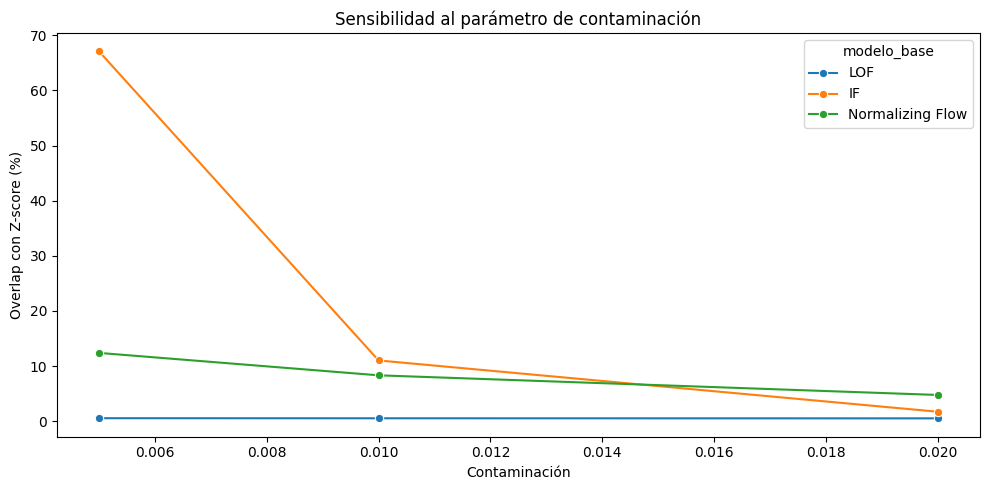

In [17]:
sens_plot = sensibilidad_contaminacion.copy()

sens_plot["contaminacion"] = (
    sens_plot["modelo"]
    .str.extract(r"c=([0-9.]+)")
    .astype(float)
)

sens_plot["modelo_base"] = (
    sens_plot["modelo"]
    .str.extract(r"^(LOF|IF|NF)")
)

sens_plot["modelo_base"] = sens_plot["modelo_base"].replace({"NF": "Normalizing Flow"})

plt.figure(figsize=(10,5))

sns.lineplot(
    data=sens_plot,
    x="contaminacion",
    y="overlap_zscore_pct",
    hue="modelo_base",
    marker="o"
)

plt.title("Sensibilidad al parámetro de contaminación")
plt.xlabel("Contaminación")
plt.ylabel("Overlap con Z-score (%)")
plt.tight_layout()
plt.show()


# Número de anomalias detectadas

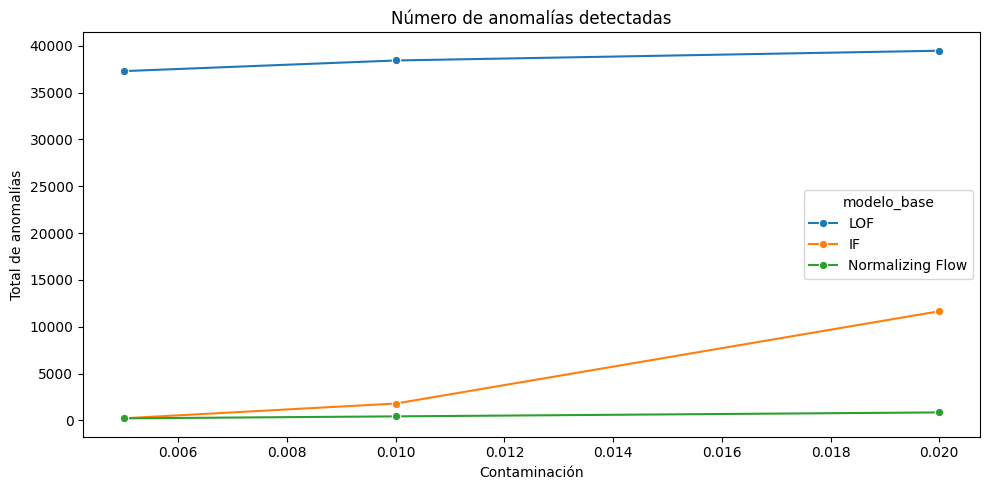

In [18]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=sens_plot,
    x="contaminacion",
    y="total_anomalias",
    hue="modelo_base",
    marker="o"
)

plt.title("Número de anomalías detectadas")
plt.xlabel("Contaminación")
plt.ylabel("Total de anomalías")
plt.tight_layout()
plt.show()

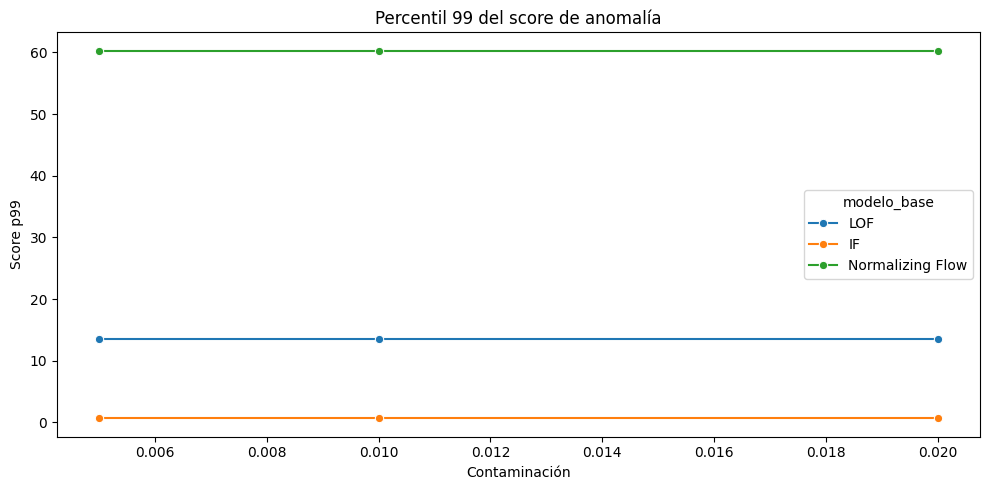

In [19]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=sens_plot,
    x="contaminacion",
    y="score_p99",
    hue="modelo_base",
    marker="o"
)

plt.title("Percentil 99 del score de anomalía")
plt.xlabel("Contaminación")
plt.ylabel("Score p99")
plt.tight_layout()
plt.show()

# DeepAR - Sensibilidad del umbral del score predictivo

In [20]:
df_deepar.columns

Index(['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'n_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'symbol', 'interval', 'log_return', 'volatility_20',
       'range_hl', 'trades_per_volume', 'buy_ratio', 'z_return',
       'anomaly_simple', 'anomaly_zscore', 'zscore_score', 'time_idx', 'hour',
       'dayofweek', 'deepar_q50', 'deepar_score', 'anomaly_deepar'],
      dtype='object')

In [21]:
deepar_thresholds = [0.995, 0.99, 0.98]
deepar_sens_results = []

for q in deepar_thresholds:
    temp = df_deepar.copy()
    thr = temp["deepar_score"].quantile(q)
    anomaly_col = f"anomaly_deepar_q{int(q*1000)}"
    
    temp[anomaly_col] = temp["deepar_score"] >= thr
    
    deepar_sens_results.append({
        "modelo": f"DeepAR_q={q}",
        "criterio": f"Top {(1-q)*100:.1f}%",
        "threshold": thr,
        "total_observaciones": len(temp),
        "total_anomalias": temp[anomaly_col].sum(),
        "anomaly_rate": temp[anomaly_col].mean(),
        "score_media": temp["deepar_score"].mean(),
        "score_std": temp["deepar_score"].std(),
        "score_p95": temp["deepar_score"].quantile(0.95),
        "score_p99": temp["deepar_score"].quantile(0.99),
        "score_max": temp["deepar_score"].max()
    })

sensibilidad_deepar = pd.DataFrame(deepar_sens_results)
display(sensibilidad_deepar)

,modelo,criterio,threshold,total_observaciones,total_anomalias,anomaly_rate,score_media,score_std,score_p95,score_p99,score_max
0,DeepAR_q=0.995,Top 0.5%,0.013866,42058,211,0.005017,0.002187,0.002429,0.006759,0.011719,0.037904
1,DeepAR_q=0.99,Top 1.0%,0.011719,42058,421,0.010010,0.002187,0.002429,0.006759,0.011719,0.037904
2,DeepAR_q=0.98,Top 2.0%,0.009277,42058,842,0.020020,0.002187,0.002429,0.006759,0.011719,0.037904


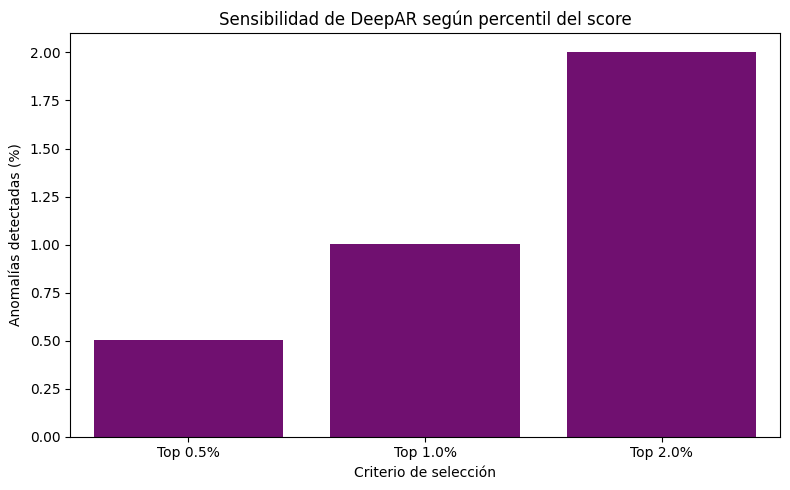

In [22]:
sensibilidad_deepar["anomaly_rate_pct"] = sensibilidad_deepar["anomaly_rate"] * 100

plt.figure(figsize=(8,5))

sns.barplot(
    data=sensibilidad_deepar,
    x="criterio",
    y="anomaly_rate_pct",
    color="purple"
)

plt.title("Sensibilidad de DeepAR según percentil del score")
plt.xlabel("Criterio de selección")
plt.ylabel("Anomalías detectadas (%)")
plt.tight_layout()
plt.show()

# Overlap Z-Score

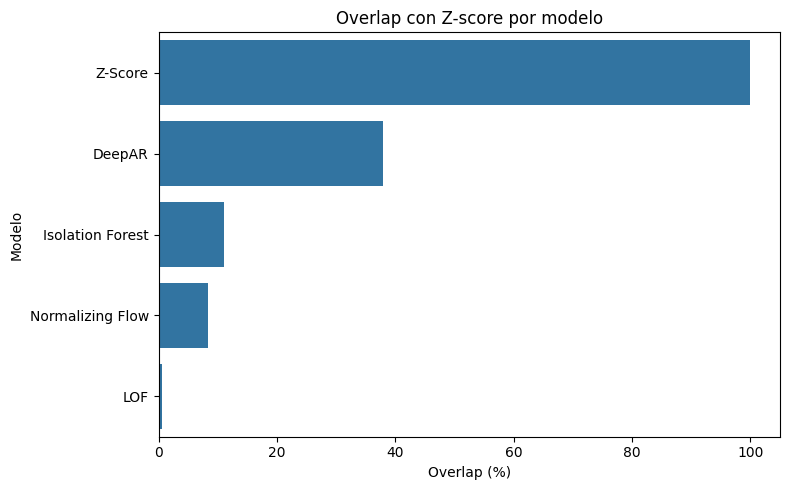

In [23]:
plt.figure(figsize=(8,5))

orden = metrics_all.sort_values(
    "overlap_zscore_pct",
    ascending=False
)

sns.barplot(
    data=orden,
    y="modelo",
    x="overlap_zscore_pct"
)

plt.title("Overlap con Z-score por modelo")
plt.xlabel("Overlap (%)")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

# Percentiles extremos de rendimiento

In [24]:
def agregar_percentiles_return(df, return_col="log_return"):
    out = df.copy()

    thr_p99 = out[return_col].abs().quantile(0.99)
    thr_p995 = out[return_col].abs().quantile(0.995)

    out["p99_return"] = out[return_col].abs() >= thr_p99
    out["p995_return"] = out[return_col].abs() >= thr_p995

    return out

def overlap_percentil(df, anomaly_col, ref_col):
    a = set(df.index[df[anomaly_col].astype(bool)])
    b = set(df.index[df[ref_col].astype(bool)])

    return len(a & b) / max(len(a), 1) * 100

In [25]:
df_if = agregar_percentiles_return(df_if)
df_lof = agregar_percentiles_return(df_lof)

if "df_flow" in globals() and not df_flow.empty:
    df_flow = agregar_percentiles_return(df_flow)

if "df_deepar" in globals() and not df_deepar.empty:
    df_deepar = agregar_percentiles_return(df_deepar)


In [26]:
overlap_rows = [
    {
        "modelo": "LOF",
        "overlap_p99_return": overlap_percentil(df_lof, "anomaly_lof", "p99_return"),
        "overlap_p995_return": overlap_percentil(df_lof, "anomaly_lof", "p995_return")
    },
    {
        "modelo": "Isolation Forest",
        "overlap_p99_return": overlap_percentil(df_if, "anomaly_if", "p99_return"),
        "overlap_p995_return": overlap_percentil(df_if, "anomaly_if", "p995_return")
    }
]

if "df_flow" in globals() and not df_flow.empty:
    overlap_rows.append({
        "modelo": "Normalizing Flow",
        "overlap_p99_return": overlap_percentil(df_flow, "anomaly_flow", "p99_return"),
        "overlap_p995_return": overlap_percentil(df_flow, "anomaly_flow", "p995_return")
    })

if "df_deepar" in globals() and not df_deepar.empty:
    overlap_rows.append({
        "modelo": "DeepAR",
        "overlap_p99_return": overlap_percentil(df_deepar, "anomaly_deepar", "p99_return"),
        "overlap_p995_return": overlap_percentil(df_deepar, "anomaly_deepar", "p995_return")
    })

overlap_extremos = pd.DataFrame(overlap_rows)
display(overlap_extremos)


,modelo,overlap_p99_return,overlap_p995_return
0,LOF,1.097786,0.548893
1,Isolation Forest,20.849637,11.738401
2,Normalizing Flow,14.251781,8.313539
3,DeepAR,49.168646,38.717340


## 14. Validación por ventanas temporales

Esta validación permite observar si las anomalías se concentran en algunos periodos específicos o si el modelo mantiene una detección más estable a lo largo del tiempo.

In [27]:
estabilidades = []

modelos_estabilidad = [
    (df_lof, "LOF", "anomaly_lof"),
    (df_if, "Isolation Forest", "anomaly_if")
]

if "df_flow" in globals() and not df_flow.empty:
    modelos_estabilidad.append((df_flow, "Normalizing Flow", "anomaly_flow"))

if "df_deepar" in globals() and not df_deepar.empty:
    modelos_estabilidad.append((df_deepar, "DeepAR", "anomaly_deepar"))

for df_modelo, nombre_modelo, col_anomalia in modelos_estabilidad:
    if col_anomalia in df_modelo.columns:
        est = estabilidad_por_ventana(
            df_modelo,
            col_anomalia,
            freq="Q"
        )
        est["modelo"] = nombre_modelo
        estabilidades.append(est)

estabilidad_modelos = pd.concat(estabilidades, ignore_index=True)

display(estabilidad_modelos.head())


,window,anomaly_rate,modelo
0,2024Q4,0.877636,LOF
1,2025Q1,0.897222,LOF
2,2025Q2,0.902129,LOF
3,2025Q3,0.882133,LOF
4,2025Q4,0.978148,LOF


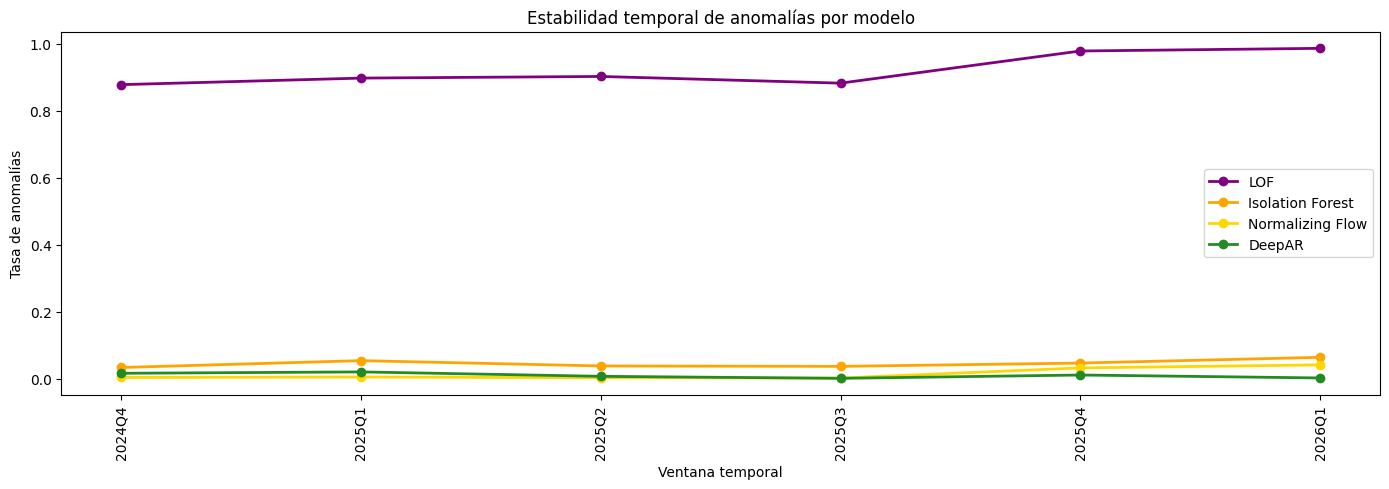

In [28]:
plt.figure(figsize=(14, 5))

colors = {
    "LOF": "purple",
    "Isolation Forest": "orange",
    "Normalizing Flow": "gold",
    "DeepAR": "forestgreen"
}

for modelo in estabilidad_modelos["modelo"].unique():
    temp = estabilidad_modelos[estabilidad_modelos["modelo"] == modelo]

    plt.plot(
        temp["window"],
        temp["anomaly_rate"],
        marker="o",
        linewidth=2,
        label=modelo,
        color=colors.get(modelo, None)
    )

plt.xticks(rotation=90)
plt.ylabel("Tasa de anomalías")
plt.xlabel("Ventana temporal")
plt.title("Estabilidad temporal de anomalías por modelo")
plt.legend()
plt.tight_layout()
plt.show()


## 14.1 Validación walk-forward multmodelo

En esta sección se implementa una validación walk-forward para evaluar el comportamiento temporal fuera de muestra de los modelos. En cada iteración, el conjunto de entrenamiento se expande progresivamente con información histórica y la evaluación se realiza sobre el siguiente año disponible. Esta estrategia permite analizar la estabilidad de la tasa de anomalías y el porcentaje de coincidencia con Z-Score en periodos futuros no utilizados durante el ajuste de los modelos.


In [45]:
# ==========================================
# Validación walk-forward multmodelo
# ==========================================

# Nota: DeepAR se deja como opcional porque reentrenarlo en cada ventana puede tardar varias horas.
RUN_DEEPAR_WALK_FORWARD = False

WF_CONTAMINATION = 0.01
WF_TRAIN_YEARS_MIN = 3
WF_MIN_TEST_OBS = 10000   # evita usar años incompletos, por ejemplo 2026 si solo contiene pocos registros


def preparar_walk_forward_data(df_in, features=FEATURES, min_test_obs=WF_MIN_TEST_OBS):
    """Prepara los datos y define los años válidos para la validación walk-forward."""
    d = df_in.copy()
    d["open_time"] = pd.to_datetime(d["open_time"])
    d["year"] = d["open_time"].dt.year
    d[features] = d[features].replace([np.inf, -np.inf], np.nan)
    d = d.dropna(subset=features + ["z_return"]).copy()

    years = sorted(d["year"].unique())
    valid_years = []

    for y in years:
        n_year = len(d[d["year"] == y])
        if n_year >= min_test_obs:
            valid_years.append(y)
        else:
            print(f"Año {y} excluido del walk-forward por tener solo {n_year} observaciones.")

    return d, valid_years


def calcular_metricas_walk_forward(test_df, scores, anomalies, modelo, train_years, test_year):
    """Calcula métricas homogéneas para cada ventana temporal."""
    anomalies = np.asarray(anomalies).astype(int)
    scores = np.asarray(scores, dtype=float)
    z_anom = (test_df["z_return"].abs() > 3).astype(int).values

    overlap = (
        ((anomalies == 1) & (z_anom == 1)).sum() / anomalies.sum() * 100
        if anomalies.sum() > 0 else 0
    )

    return {
        "modelo": modelo,
        "train_period": f"{min(train_years)}-{max(train_years)}",
        "test_period": test_year,
        "train_obs": len(test_df) if False else None,  # se actualiza en cada función
        "test_obs": len(test_df),
        "anomalies": int(anomalies.sum()),
        "anomaly_rate_pct": float(anomalies.mean() * 100),
        "overlap_zscore_pct": float(overlap),
        "score_mean": float(np.mean(scores)),
        "score_p95": float(np.percentile(scores, 95)),
        "score_p99": float(np.percentile(scores, 99)),
        "score_max": float(np.max(scores))
    }


def run_walk_forward_zscore(df_in, train_years_min=WF_TRAIN_YEARS_MIN):
    d, years = preparar_walk_forward_data(df_in)
    results = []

    for i in range(train_years_min, len(years)):
        train_years = years[:i]
        test_year = years[i]

        train_df_w = d[d["year"].isin(train_years)].copy()
        test_df_w = d[d["year"] == test_year].copy()

        scores = test_df_w["z_return"].abs().values
        anomalies = (scores > 3).astype(int)

        row = calcular_metricas_walk_forward(
            test_df_w, scores, anomalies, "Z-Score", train_years, test_year
        )
        row["train_obs"] = len(train_df_w)
        row["overlap_zscore_pct"] = 100.0 if row["anomalies"] > 0 else 0.0
        results.append(row)

    return pd.DataFrame(results)


def run_walk_forward_lof(df_in, contamination=WF_CONTAMINATION, n_neighbors=20, train_years_min=WF_TRAIN_YEARS_MIN):
    d, years = preparar_walk_forward_data(df_in)
    results = []

    for i in range(train_years_min, len(years)):
        train_years = years[:i]
        test_year = years[i]

        train_df_w = d[d["year"].isin(train_years)].copy()
        test_df_w = d[d["year"] == test_year].copy()

        scaler_w = StandardScaler()
        X_train_w = scaler_w.fit_transform(train_df_w[FEATURES])
        X_test_w = scaler_w.transform(test_df_w[FEATURES])

        model_w = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=contamination,
            novelty=True
        )
        model_w.fit(X_train_w)

        preds = model_w.predict(X_test_w)
        scores = -model_w.score_samples(X_test_w)
        anomalies = (preds == -1).astype(int)

        row = calcular_metricas_walk_forward(
            test_df_w, scores, anomalies, "LOF", train_years, test_year
        )
        row["train_obs"] = len(train_df_w)
        results.append(row)

    return pd.DataFrame(results)


def run_walk_forward_iforest(df_in, contamination=WF_CONTAMINATION, train_years_min=WF_TRAIN_YEARS_MIN):
    d, years = preparar_walk_forward_data(df_in)
    results = []

    for i in range(train_years_min, len(years)):
        train_years = years[:i]
        test_year = years[i]

        train_df_w = d[d["year"].isin(train_years)].copy()
        test_df_w = d[d["year"] == test_year].copy()

        scaler_w = StandardScaler()
        X_train_w = scaler_w.fit_transform(train_df_w[FEATURES])
        X_test_w = scaler_w.transform(test_df_w[FEATURES])

        model_w = IsolationForest(
            n_estimators=300,
            contamination=contamination,
            random_state=42,
            n_jobs=-1
        )
        model_w.fit(X_train_w)

        scores = -model_w.score_samples(X_test_w)
        preds = model_w.predict(X_test_w)
        anomalies = (preds == -1).astype(int)

        row = calcular_metricas_walk_forward(
            test_df_w, scores, anomalies, "Isolation Forest", train_years, test_year
        )
        row["train_obs"] = len(train_df_w)
        results.append(row)

    return pd.DataFrame(results)


def run_walk_forward_normalizing_flow(
    df_in,
    contamination=WF_CONTAMINATION,
    train_years_min=WF_TRAIN_YEARS_MIN,
    epochs=5,
    batch_size=2048,
    lr=1e-3,
    n_coupling=6,
    hidden_dim=128
):
    """Walk-forward para Normalizing Flow. Usa menos epochs por defecto para reducir tiempo."""
    if not TORCH_AVAILABLE:
        print("PyTorch no está disponible. Se omite Normalizing Flow.")
        return pd.DataFrame()

    d, years = preparar_walk_forward_data(df_in)
    results = []

    for i in range(train_years_min, len(years)):
        train_years = years[:i]
        test_year = years[i]

        train_df_w = d[d["year"].isin(train_years)].copy()
        test_df_w = d[d["year"] == test_year].copy()

        out_w, _, _, _ = train_normalizing_flow(
            train_df_w,
            test_df_w,
            FEATURES,
            contamination=contamination,
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            n_coupling=n_coupling,
            hidden_dim=hidden_dim,
            random_state=42
        )

        scores = out_w["flow_score"].values
        anomalies = out_w["anomaly_flow"].astype(int).values

        row = calcular_metricas_walk_forward(
            out_w, scores, anomalies, "Normalizing Flow", train_years, test_year
        )
        row["train_obs"] = len(train_df_w)
        results.append(row)

    return pd.DataFrame(results)


def run_walk_forward_deepar(
    df_in,
    contamination=WF_CONTAMINATION,
    train_years_min=WF_TRAIN_YEARS_MIN,
    encoder_len=96,
    pred_len=12,
    batch_size=256,
    max_epochs=3
):
    """Walk-forward para DeepAR. Puede tardar mucho porque entrena un modelo por ventana."""
    if not DEEPAR_AVAILABLE:
        print("DeepAR no está disponible. Se omite DeepAR.")
        return pd.DataFrame()

    d, years = preparar_walk_forward_data(df_in)
    results = []
    cov_reals = ["volatility_20", "range_hl", "trades_per_volume", "buy_ratio", "hour", "dayofweek"]

    for i in range(train_years_min, len(years)):
        train_years = years[:i]
        test_year = years[i]

        train_df_w = d[d["year"].isin(train_years)].copy()
        test_df_w = d[d["year"] == test_year].copy()

        deep_all = pd.concat([train_df_w, test_df_w], ignore_index=True)
        deep_all = prepare_deepar_df(deep_all)
        deep_all = deep_all.dropna(subset=["log_return"] + cov_reals + ["time_idx", "symbol"]).copy()

        train_deep = deep_all[deep_all["year"].isin(train_years)].copy()
        test_deep = deep_all[deep_all["year"] == test_year].copy()

        if len(test_deep) <= (encoder_len + pred_len + 10):
            print(f"Se omite DeepAR para {test_year}: no hay suficientes observaciones de prueba.")
            continue

        cutoff = int(train_deep["time_idx"].quantile(0.90))
        train_sub = train_deep[train_deep["time_idx"] <= cutoff].copy()
        val_sub = train_deep[train_deep["time_idx"] > cutoff].copy()

        training = TimeSeriesDataSet(
            train_sub,
            time_idx="time_idx",
            target="log_return",
            group_ids=["symbol"],
            max_encoder_length=encoder_len,
            max_prediction_length=pred_len,
            time_varying_unknown_reals=["log_return"],
            time_varying_known_reals=cov_reals,
            allow_missing_timesteps=True
        )
        validation = TimeSeriesDataSet.from_dataset(training, val_sub, predict=False, stop_randomization=True)
        testing = TimeSeriesDataSet.from_dataset(training, test_deep, predict=False, stop_randomization=True)

        train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
        val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
        test_loader = testing.to_dataloader(train=False, batch_size=512, num_workers=0)

        model_w = DeepAR.from_dataset(
            training,
            learning_rate=1e-3,
            hidden_size=32,
            rnn_layers=2,
            loss=NormalDistributionLoss()
        )

        trainer_w = Trainer(
            max_epochs=max_epochs,
            accelerator="auto",
            enable_checkpointing=False,
            logger=False,
            enable_model_summary=False
        )
        trainer_w.fit(model_w, train_loader, val_loader)

        samples = model_w.predict(test_loader, mode="samples", n_samples=100)
        samples = samples.detach().cpu().numpy()
        q50 = np.quantile(samples, 0.50, axis=-1)[:, 0]

        df_pred = test_deep.iloc[-len(q50):].copy()
        df_pred["deepar_q50"] = q50
        df_pred["deepar_score"] = np.abs(df_pred["log_return"].values - q50)

        threshold = df_pred["deepar_score"].quantile(1 - contamination)
        df_pred["anomaly_deepar"] = df_pred["deepar_score"] >= threshold

        scores = df_pred["deepar_score"].values
        anomalies = df_pred["anomaly_deepar"].astype(int).values

        row = calcular_metricas_walk_forward(
            df_pred, scores, anomalies, "DeepAR", train_years, test_year
        )
        row["train_obs"] = len(train_df_w)
        results.append(row)

    return pd.DataFrame(results)


In [46]:
# Ejecutar validación walk-forward
# Para Normalizing Flow se usan 5 epochs por defecto para reducir el tiempo de ejecución.
# Si deseas replicar exactamente la configuración principal del modelo, cambia nf_epochs=15.

walk_forward_zscore = run_walk_forward_zscore(df_model)
walk_forward_lof = run_walk_forward_lof(df_model, contamination=0.01, n_neighbors=20)
walk_forward_iforest = run_walk_forward_iforest(df_model, contamination=0.01)
walk_forward_nf = run_walk_forward_normalizing_flow(df_model, contamination=0.01, epochs=5)

walk_forward_parts = [
    walk_forward_zscore,
    walk_forward_lof,
    walk_forward_iforest
]

if not walk_forward_nf.empty:
    walk_forward_parts.append(walk_forward_nf)

if RUN_DEEPAR_WALK_FORWARD:
    walk_forward_deepar = run_walk_forward_deepar(
        df_model,
        contamination=0.01,
        max_epochs=3
    )
    if not walk_forward_deepar.empty:
        walk_forward_parts.append(walk_forward_deepar)
else:
    print("DeepAR walk-forward no se ejecutó. Cambia RUN_DEEPAR_WALK_FORWARD = True si deseas entrenarlo por ventana.")

walk_forward_all = pd.concat(walk_forward_parts, ignore_index=True)

display(walk_forward_all)


Año 2026 excluido del walk-forward por tener solo 1151 observaciones.
Año 2026 excluido del walk-forward por tener solo 1151 observaciones.
Año 2026 excluido del walk-forward por tener solo 1151 observaciones.
Año 2026 excluido del walk-forward por tener solo 1151 observaciones.
Epoch 1/5 - NLL: 4.918970
Epoch 2/5 - NLL: 4.284017
Epoch 3/5 - NLL: 4.236733
Epoch 4/5 - NLL: 4.221778
Epoch 5/5 - NLL: 4.213046
Epoch 1/5 - NLL: 4.992899
Epoch 2/5 - NLL: 4.229156
Epoch 3/5 - NLL: 4.170900
Epoch 4/5 - NLL: 4.146305
Epoch 5/5 - NLL: 4.142028
Epoch 1/5 - NLL: 4.853370
Epoch 2/5 - NLL: 4.347795
Epoch 3/5 - NLL: 4.308946
Epoch 4/5 - NLL: 4.291287
Epoch 5/5 - NLL: 4.285980
Epoch 1/5 - NLL: 4.660967
Epoch 2/5 - NLL: 4.274190
Epoch 3/5 - NLL: 4.245589
Epoch 4/5 - NLL: 4.233607
Epoch 5/5 - NLL: 4.225566
Epoch 1/5 - NLL: 4.177538
Epoch 2/5 - NLL: 3.626131
Epoch 3/5 - NLL: 3.588443
Epoch 4/5 - NLL: 3.572223
Epoch 5/5 - NLL: 3.560719
DeepAR walk-forward no se ejecutó. Cambia RUN_DEEPAR_WALK_FORWARD = Tr

,modelo,train_period,test_period,train_obs,test_obs,anomalies,anomaly_rate_pct,overlap_zscore_pct,score_mean,score_p95,score_p99,score_max
0,Z-Score,2018-2020,2021,104730,34970,1189,3.400057,100.000000,0.851869,2.536084,4.623334,28.612925
1,Z-Score,2018-2021,2022,139700,35040,487,1.389840,100.000000,0.563329,1.777955,3.368838,15.070323
2,Z-Score,2018-2022,2023,174740,35030,166,0.473880,100.000000,0.361571,1.099605,2.302470,25.101678
3,Z-Score,2018-2023,2024,209770,35136,243,0.691598,100.000000,0.498911,1.483130,2.684930,12.243461
4,Z-Score,2018-2024,2025,244906,35040,152,0.433790,100.000000,0.413239,1.248809,2.282289,9.576293
5,LOF,2018-2020,2021,104730,34970,7948,22.728053,12.204328,1.228651,1.689773,2.379354,12.132846
6,LOF,2018-2021,2022,139700,35040,1513,4.317922,0.991408,1.069109,1.261270,1.518036,2.242903
7,LOF,2018-2022,2023,174740,35030,1792,5.115615,0.334821,1.078801,1.271520,1.557566,3.682668
8,LOF,2018-2023,2024,209770,35136,13668,38.900273,1.412057,1.673469,4.328538,7.973807,23.704630
9,LOF,2018-2024,2025,244906,35040,2986,8.521689,3.516410,1.092971,1.367710,1.743882,4.912647


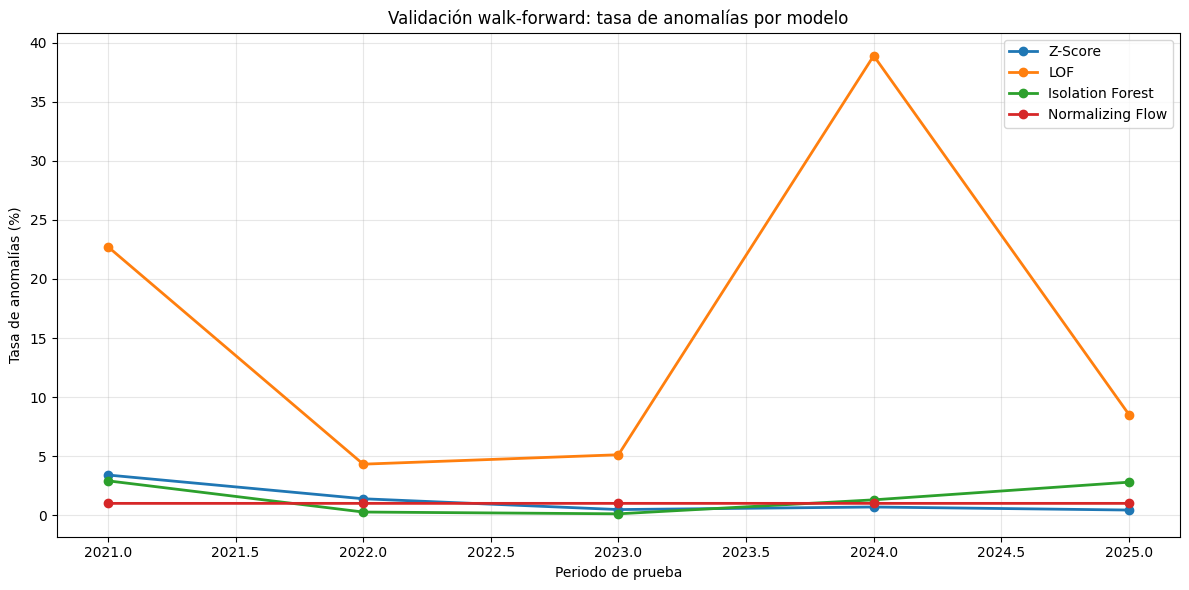

In [47]:
plt.figure(figsize=(12, 6))

for modelo in walk_forward_all["modelo"].unique():
    temp = walk_forward_all[walk_forward_all["modelo"] == modelo]
    plt.plot(
        temp["test_period"],
        temp["anomaly_rate_pct"],
        marker="o",
        linewidth=2,
        label=modelo
    )

plt.xlabel("Periodo de prueba")
plt.ylabel("Tasa de anomalías (%)")
plt.title("Validación walk-forward: tasa de anomalías por modelo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


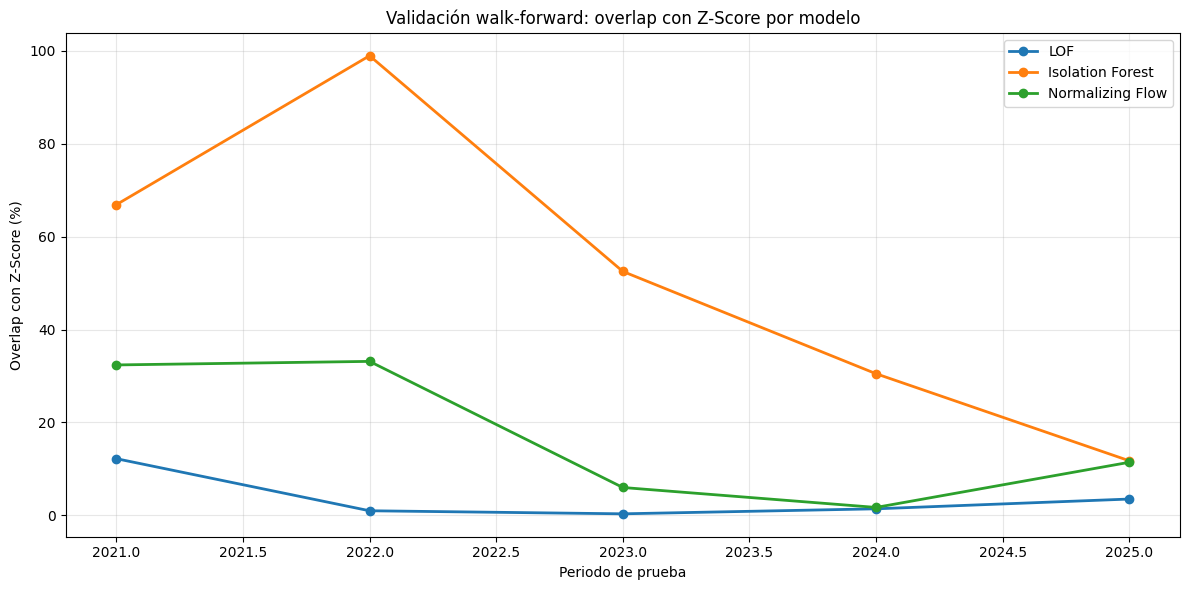

In [48]:
plt.figure(figsize=(12, 6))

for modelo in walk_forward_all["modelo"].unique():
    if modelo == "Z-Score":
        continue
    temp = walk_forward_all[walk_forward_all["modelo"] == modelo]
    plt.plot(
        temp["test_period"],
        temp["overlap_zscore_pct"],
        marker="o",
        linewidth=2,
        label=modelo
    )

plt.xlabel("Periodo de prueba")
plt.ylabel("Overlap con Z-Score (%)")
plt.title("Validación walk-forward: overlap con Z-Score por modelo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [49]:
# Resumen agregado de estabilidad walk-forward por modelo
walk_forward_resumen = (
    walk_forward_all
    .groupby("modelo")
    .agg(
        ventanas=("test_period", "count"),
        anomaly_rate_promedio=("anomaly_rate_pct", "mean"),
        anomaly_rate_std=("anomaly_rate_pct", "std"),
        overlap_zscore_promedio=("overlap_zscore_pct", "mean"),
        overlap_zscore_std=("overlap_zscore_pct", "std"),
        score_p99_promedio=("score_p99", "mean")
    )
    .reset_index()
)

display(walk_forward_resumen)


,modelo,ventanas,anomaly_rate_promedio,anomaly_rate_std,overlap_zscore_promedio,overlap_zscore_std,score_p99_promedio
0,Isolation Forest,5,1.475914,1.336041,52.103438,33.564787,0.631558
1,LOF,5,15.916711,14.836782,3.691805,4.905419,3.034529
2,Normalizing Flow,5,0.998767,0.000445,16.931811,14.856830,24.617603
3,Z-Score,5,1.277833,1.246876,100.000000,0.000000,3.052372


## 15. Análisis por régimen de volatilidad

Como aproximación a los regímenes de mercado, se clasifican las observaciones en baja, media y alta volatilidad con base en terciles de `volatility_20`. Esto permite evaluar si los modelos tienden a detectar más anomalías en periodos de mayor incertidumbre.

In [29]:
def add_volatility_regime(df_in):
    d = df_in.copy()

    d["vol_regime"] = pd.qcut(
        d["volatility_20"],
        q=3,
        labels=[
            "baja_volatilidad",
            "media_volatilidad",
            "alta_volatilidad"
        ]
    )

    return d

In [30]:
reg_lof = add_volatility_regime(df_lof)
reg_if = add_volatility_regime(df_if)

if "df_flow" in globals() and not df_flow.empty:
    reg_flow = add_volatility_regime(df_flow)

if "df_deepar" in globals() and not df_deepar.empty:
    reg_deepar = add_volatility_regime(df_deepar)


In [31]:
regime_parts = [
    reg_lof.groupby("vol_regime")["anomaly_lof"]
    .mean()
    .reset_index()
    .assign(modelo="LOF")
    .rename(columns={"anomaly_lof":"anomaly_rate"}),

    reg_if.groupby("vol_regime")["anomaly_if"]
    .mean()
    .reset_index()
    .assign(modelo="Isolation Forest")
    .rename(columns={"anomaly_if":"anomaly_rate"})
]

if "reg_flow" in globals():
    regime_parts.append(
        reg_flow.groupby("vol_regime")["anomaly_flow"]
        .mean()
        .reset_index()
        .assign(modelo="Normalizing Flow")
        .rename(columns={"anomaly_flow":"anomaly_rate"})
    )

if "reg_deepar" in globals():
    regime_parts.append(
        reg_deepar.groupby("vol_regime")["anomaly_deepar"]
        .mean()
        .reset_index()
        .assign(modelo="DeepAR")
        .rename(columns={"anomaly_deepar":"anomaly_rate"})
    )

regime_summary = pd.concat(regime_parts, ignore_index=True)
display(regime_summary)


,vol_regime,anomaly_rate,modelo
0,baja_volatilidad,0.911989,LOF
1,media_volatilidad,0.903451,LOF
2,alta_volatilidad,0.919602,LOF
3,baja_volatilidad,0.037353,Isolation Forest
4,media_volatilidad,0.019424,Isolation Forest
5,alta_volatilidad,0.070509,Isolation Forest
6,baja_volatilidad,0.004767,Normalizing Flow
7,media_volatilidad,0.007684,Normalizing Flow
8,alta_volatilidad,0.017503,Normalizing Flow
9,baja_volatilidad,0.000000,DeepAR


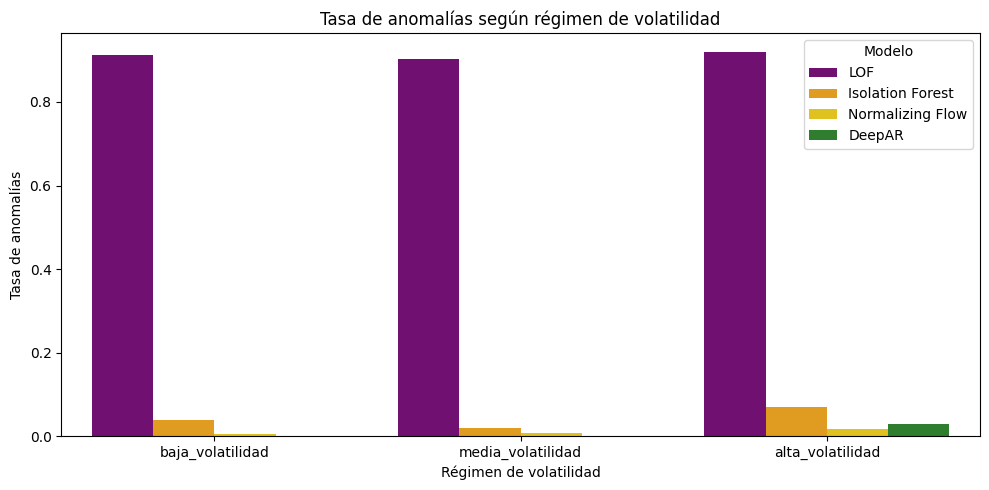

In [32]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=regime_summary,
    x="vol_regime",
    y="anomaly_rate",
    hue="modelo",
    palette={
        "LOF":"purple",
        "Isolation Forest":"orange",
        "Normalizing Flow":"gold",
        "DeepAR":"forestgreen"
    }
)

plt.title("Tasa de anomalías según régimen de volatilidad")
plt.xlabel("Régimen de volatilidad")
plt.ylabel("Tasa de anomalías")
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()


## 16. Interpretación financiera de anomalías

Las anomalías detectadas se clasifican según su posible significado financiero: shock de precio, cambio de volatilidad, rango de precio extremo, actividad transaccional extrema, desequilibrio de compra-venta o comportamiento mixto. Esta clasificación no implica causalidad, pero permite convertir los resultados en hallazgos interpretables.

In [33]:
# Ejemplo con Isolation Forest como modelo principal interpretable
anom_if = df_if[df_if["anomaly_if"] == True].copy()
anom_if["tipo_anomalia"] = anom_if.apply(clasificar_tipo_anomalia, axis=1)

resumen_tipo = anom_if["tipo_anomalia"].value_counts().reset_index()
resumen_tipo.columns = ["tipo_anomalia", "total"]
display(resumen_tipo)

display(anom_if[["open_time", "close", "log_return", "volatility_20", "range_hl", "trades_per_volume", "buy_ratio", "if_score", "tipo_anomalia"]].head(20))

,tipo_anomalia,total
0,desequilibrio_compra_venta,823
1,atipico_multivariado,697
2,shock_precio,141
3,mixto,73
4,cambio_volatilidad,32
5,rango_precio_extremo,13
6,actividad_transaccional_extrema,10


,open_time,close,log_return,volatility_20,range_hl,trades_per_volume,buy_ratio,if_score,tipo_anomalia
239058,2024-11-01 02:00:00+00:00,69042.01,-0.005201,0.002704,0.010201,86.593347,0.348301,0.644403,atipico_multivariado
239112,2024-11-01 15:30:00+00:00,69945.71,-0.013184,0.004297,0.016057,95.721643,0.367314,0.692660,shock_precio
239113,2024-11-01 15:45:00+00:00,69387.77,-0.008009,0.004625,0.013010,108.788837,0.399511,0.650312,atipico_multivariado
239114,2024-11-01 16:00:00+00:00,70032.61,0.009250,0.005070,0.009809,119.775898,0.662204,0.667959,atipico_multivariado
239154,2024-11-02 02:00:00+00:00,69746.00,0.001118,0.001761,0.001285,116.520950,0.784391,0.647325,desequilibrio_compra_venta
239250,2024-11-03 02:00:00+00:00,68686.00,-0.004708,0.001417,0.005727,90.610327,0.267215,0.658766,desequilibrio_compra_venta
239251,2024-11-03 02:15:00+00:00,68232.01,-0.006632,0.001948,0.007920,106.786670,0.347310,0.648808,atipico_multivariado
239316,2024-11-03 18:30:00+00:00,67913.54,-0.005733,0.002896,0.005809,160.971914,0.292314,0.650565,atipico_multivariado
239424,2024-11-04 21:30:00+00:00,67012.00,-0.007137,0.002957,0.009167,144.799723,0.366653,0.648243,atipico_multivariado
239464,2024-11-05 07:30:00+00:00,68918.00,0.004858,0.001780,0.005541,115.220372,0.781420,0.658810,desequilibrio_compra_venta


## 17. Visualización de anomalías sobre la serie de precio

La inspección visual permite revisar si los puntos detectados se asocian con episodios relevantes de precio, volatilidad o actividad transaccional. Esta revisión complementa las métricas cuantitativas en ausencia de etiquetas reales.

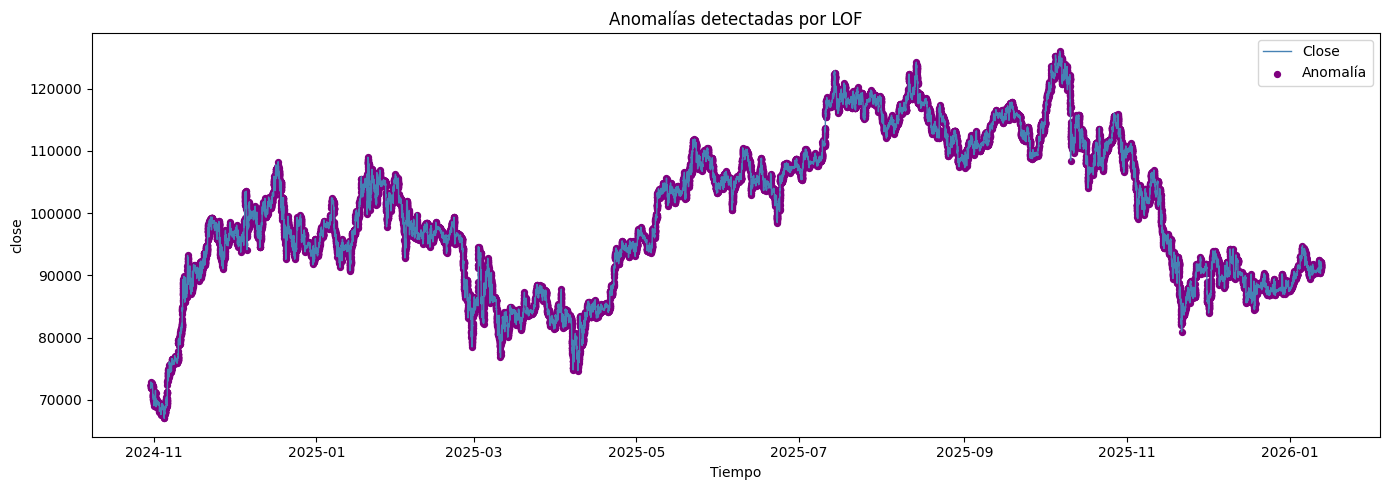

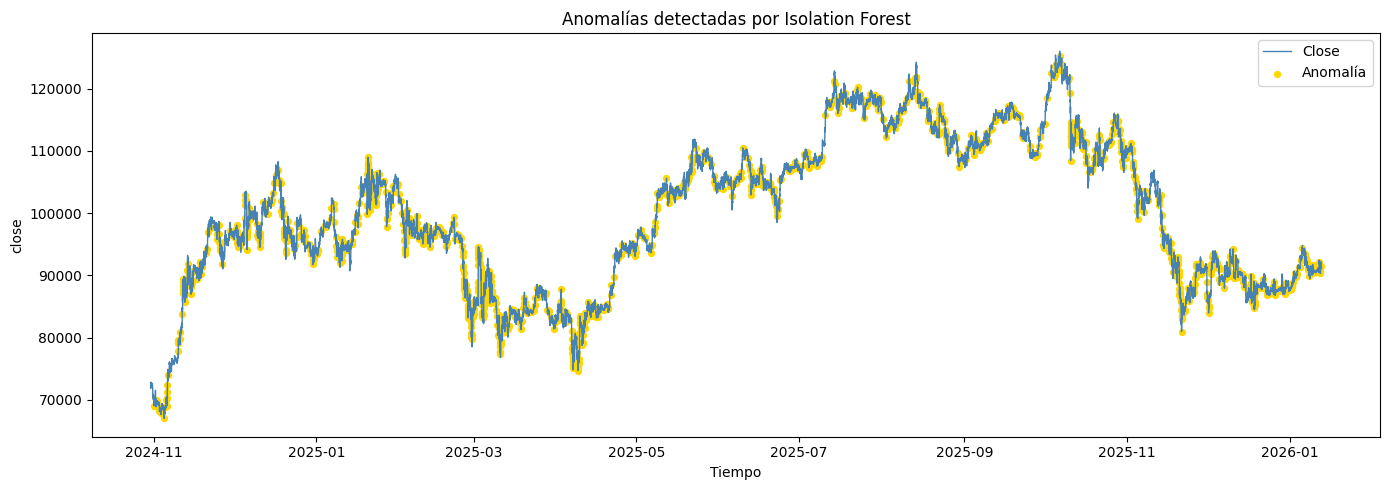

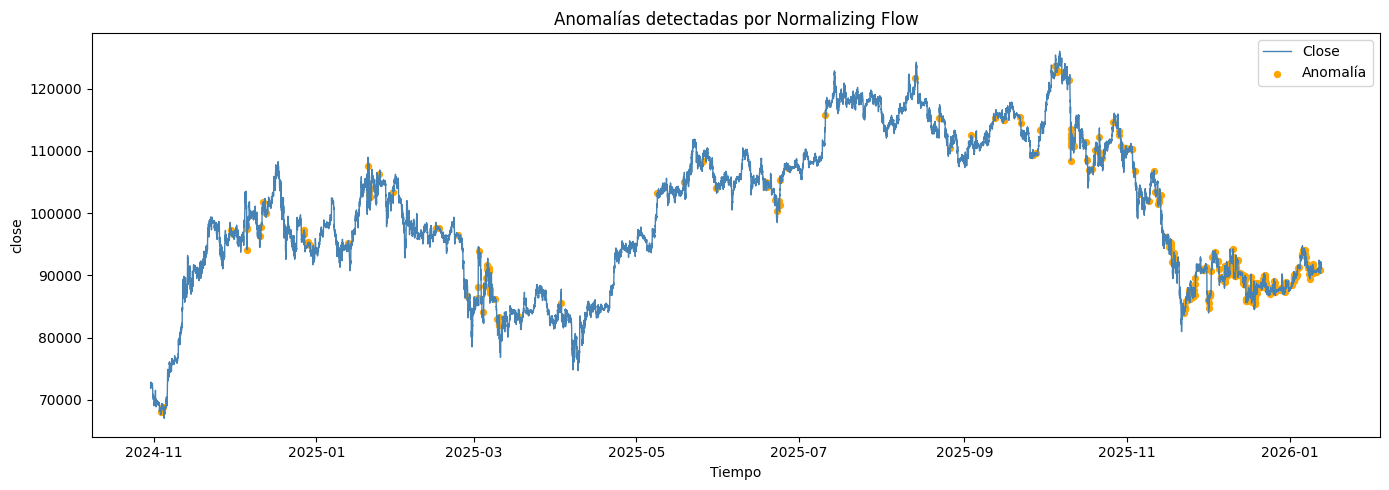

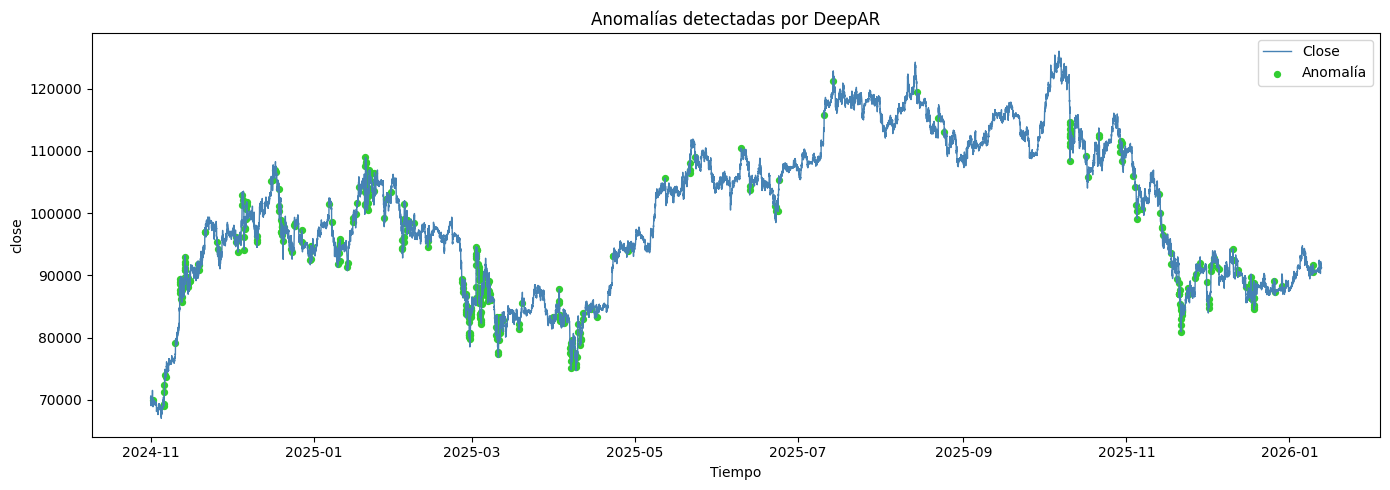

In [34]:
def plot_price_anomalies(
    df_in,
    anomaly_col,
    title,
    time_col="open_time",
    price_col="close",
    anomaly_color="red"
):
    d = df_in.dropna(subset=[anomaly_col]).copy()

    x = d[time_col] if time_col in d.columns else d.index

    plt.figure(figsize=(14, 5))
    plt.plot(x, d[price_col], linewidth=1, label="Close", color="steelblue")

    an = d[d[anomaly_col].astype(bool)]
    x_an = an[time_col] if time_col in an.columns else an.index

    plt.scatter(
        x_an,
        an[price_col],
        s=18,
        color=anomaly_color,
        label="Anomalía"
    )

    plt.title(title)
    plt.xlabel("Tiempo")
    plt.ylabel(price_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Morado
plot_price_anomalies(
    df_lof,
    "anomaly_lof",
    "Anomalías detectadas por LOF",
    anomaly_color="purple"
)

# Amarillo
plot_price_anomalies(
    df_if,
    "anomaly_if",
    "Anomalías detectadas por Isolation Forest",
    anomaly_color="gold"
)

# Naranja
if "df_flow" in globals() and not df_flow.empty:
    plot_price_anomalies(
        df_flow,
        "anomaly_flow",
        "Anomalías detectadas por Normalizing Flow",
        anomaly_color="orange"
    )

# Verde opcional
if "df_deepar" in globals() and not df_deepar.empty:
    plot_price_anomalies(
        df_deepar,
        "anomaly_deepar",
        "Anomalías detectadas por DeepAR",
        anomaly_color="limegreen"
    )


## 18. Criterio de selección del modelo

La selección del modelo más adecuado no se basa únicamente en la tasa de anomalías ni en el overlap con Z-Score. Para esta investigación se recomienda considerar cinco criterios: interpretabilidad, estabilidad temporal, costo computacional, coherencia financiera y utilidad para el monitoreo de riesgo.

In [50]:
criterios = pd.DataFrame({
    "criterio": ["Interpretabilidad", "Estabilidad temporal", "Costo computacional", "Coherencia financiera", "Utilidad para monitoreo"],
    "descripcion": [
        "Facilidad para explicar por qué una observación fue clasificada como anómala.",
        "Capacidad de mantener tasas de detección razonables en diferentes ventanas temporales.",
        "Tiempo y recursos necesarios para entrenar y aplicar el modelo.",
        "Relación entre las anomalías detectadas y eventos extremos de precio, volatilidad o volumen.",
        "Capacidad de apoyar alertas tempranas y análisis de riesgo financiero."
    ]
})
display(criterios)

,criterio,descripcion
0,Interpretabilidad,Facilidad para explicar por qué una observació...
1,Estabilidad temporal,Capacidad de mantener tasas de detección razon...
2,Costo computacional,Tiempo y recursos necesarios para entrenar y a...
3,Coherencia financiera,Relación entre las anomalías detectadas y even...
4,Utilidad para monitoreo,Capacidad de apoyar alertas tempranas y anális...


## 19. Guardado de resultados

Esta sección exporta métricas y anomalías detectadas para facilitar la documentación, trazabilidad y reproducibilidad del análisis.

In [53]:
OUTPUT_DIR = r"C:\Users\cecil\Cript_Anomalies\resultados_modelos_reducidos"

os.makedirs(OUTPUT_DIR, exist_ok=True)

metrics_all.to_csv(os.path.join(OUTPUT_DIR, "metricas_modelos.csv"), index=False)
df_lof.to_csv(os.path.join(OUTPUT_DIR, "resultados_lof.csv"), index=False)
df_if.to_csv(os.path.join(OUTPUT_DIR, "resultados_isolation_forest.csv"), index=False)

if "df_flow" in globals() and not df_flow.empty:
    df_flow.to_csv(os.path.join(OUTPUT_DIR, "resultados_normalizing_flow.csv"), index=False)
if "df_deepar" in globals() and not df_deepar.empty:
    df_deepar.to_csv(os.path.join(OUTPUT_DIR, "resultados_deepar.csv"), index=False)

print("Archivos guardados en:", OUTPUT_DIR)


Archivos guardados en: C:\Users\cecil\Cript_Anomalies\resultados_modelos_reducidos
